In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

## Helper Functions
- Generate samples of low rank matrices and their singular values
- Compute desired statistics from a set of eigenvalues
- Aggregate and plot samples

In [2]:
w_bins = np.linspace(-5, 5, 41)
sv_bins = np.linspace(0, 100, 51)
def generate_low_rank(d_n, d_m, mu=0, sigma=1):
    W_Q = np.random.normal(loc=mu, scale=sigma, size=d_n * d_m).reshape(d_n, d_m)
    W_K = np.random.normal(loc=mu, scale=sigma, size=d_n * d_m).reshape(d_m, d_n)
    W_QK = W_Q @ W_K / np.sqrt(d_n)
    _, S, _ = torch.linalg.svd(torch.tensor(W_QK))
    P_w, _ = np.histogram(W_QK.flatten(), w_bins, density=True)
    P_s, _ = np.histogram(S, sv_bins, density=True)
    return S, torch.tensor(P_w, dtype=float), torch.tensor(P_s, dtype=float)

In [3]:
def compute_eig_stat(eigenvalues, stat_type, d_model, d_head):
    """Compute a statistic from eigenvalues (squared singular values)."""
    lam = eigenvalues
    if stat_type == "max":
        return np.max(lam)
    elif stat_type == "condition_number":
        lam_nz = lam[:d_head]
        if len(lam_nz) > 0 and lam_nz[-1] > 0:
            return lam_nz[0] / lam_nz[-1]
        return 0
    elif stat_type == "participation_ratio":
        return np.sum(lam)**2 / np.sum(lam**2) if np.sum(lam**2) > 0 else 0
    elif stat_type == "normalized_participation_ratio":
        pr = np.sum(lam)**2 / np.sum(lam**2) if np.sum(lam**2) > 0 else 0
        return pr / d_head if d_head > 0 else 0
    elif stat_type == "spectral_entropy":
        s = np.sum(lam)
        if s > 0:
            p = lam / s
            p = p[p > 0]
            return -np.sum(p * np.log(p))
        return 0
    elif stat_type == "stable_rank":
        return np.sum(lam**2) / np.max(lam)**2 if np.max(lam) > 0 else 0
    return 0

In [20]:
def collect_eig_stats(d_model, d_head, n_samples=500, sigma=1.0):
    """Generate n_samples random low-rank W_QK and compute eigenvalue statistics."""
    stat_names = [
        "max", "participation_ratio", "normalized_participation_ratio",
        "spectral_entropy", "condition_number", "stable_rank"
    ]
    stats = {k: np.zeros(n_samples) for k in stat_names}
    singular_values = []
    for i in range(n_samples):
        S, _, _ = generate_low_rank(d_model, d_head, mu=0, sigma=sigma)
        S_np = S.numpy() if hasattr(S, 'numpy') else np.array(S)
        singular_values.extend(S_np)
        eigenvalues = S_np**2  # squared singular values
        for k in stat_names:
            stats[k][i] = compute_eig_stat(eigenvalues, k, d_model, d_head)
    return stats, singular_values


def plot_stat_distributions(stats, d_model, d_head, n_bins=40):
    """Plot histograms of each eigenvalue statistic."""
    nice_names = {
        "max": r"$\lambda_{\max}$",
        "participation_ratio": r"PR $= (\sum \lambda)^2 / \sum \lambda^2$",
        "normalized_participation_ratio": r"Normalized PR / $d_h$",
        "spectral_entropy": r"Spectral entropy $-\sum p_i \ln p_i$",
        "condition_number": r"Condition number $\lambda_1 / \lambda_{d_h}$",
        "stable_rank": r"Stable rank $\sum \lambda^2 / \lambda_{\max}^2$",
    }
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()
    for idx, (key, vals) in enumerate(stats.items()):
        ax = axes[idx]
        ax.hist(vals, bins=n_bins, density=True, alpha=0.7, edgecolor='k', linewidth=0.3)
        ax.set_xlabel(nice_names.get(key, key), fontsize=10)
        ax.set_ylabel("Density")
        mean, std = np.mean(vals), np.std(vals)
        ax.axvline(mean, color='red', ls='--', lw=1.2, label=f"mean={mean:.2f}")
        ax.legend(fontsize=8)
        ax.set_title(f"d={d_model}, d_h={d_head}", fontsize=9)
    plt.tight_layout()
    plt.show()
    return fig

## Distributions of Eigenvalue Statistics from Random $W_{QK}$
Sample many random $W_{QK} = W_Q W_K / \sqrt{d}$ at fixed $(d, d_h)$ and compute
statistics from the eigenvalues $\lambda_i = s_i^2$: max eigenvalue, participation
ratio, normalized PR, spectral entropy, condition number, and stable rank.

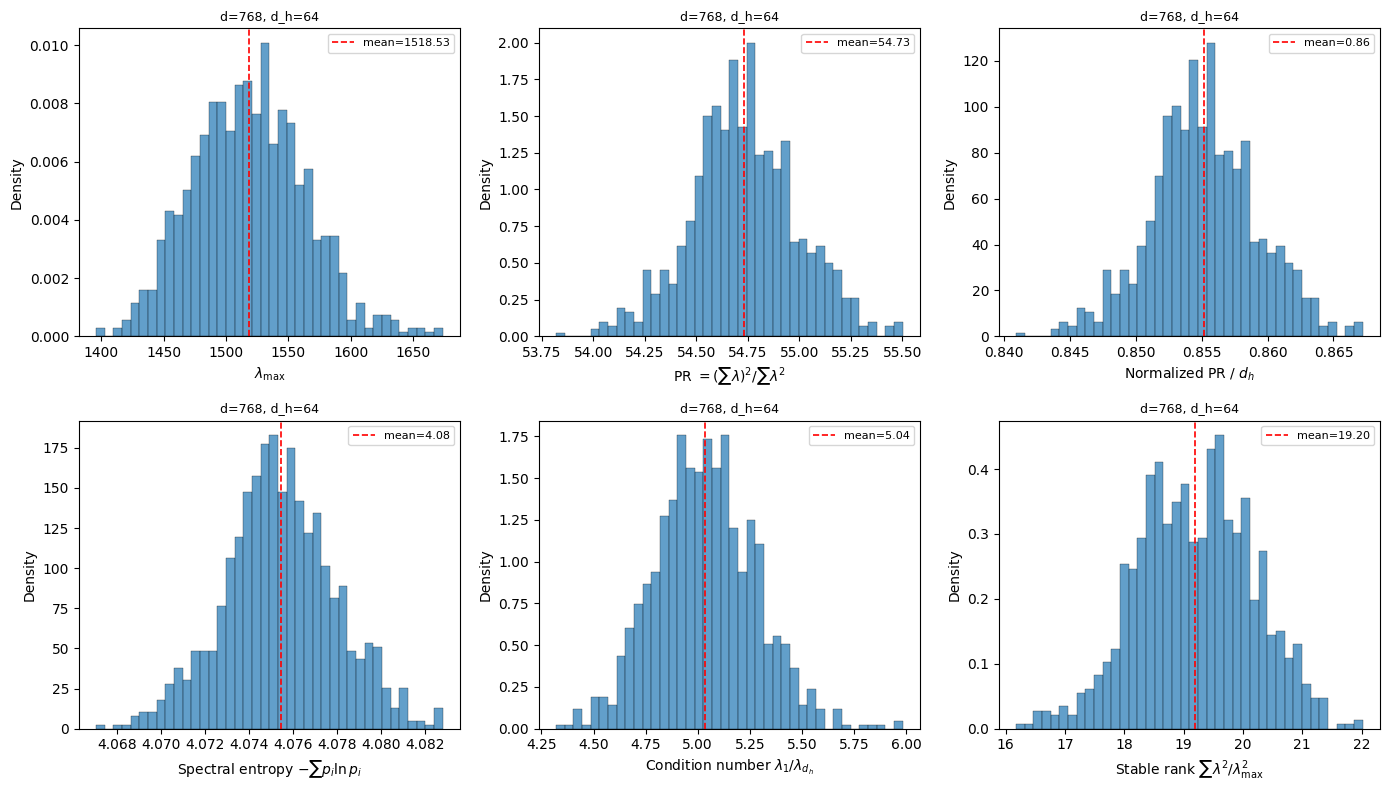

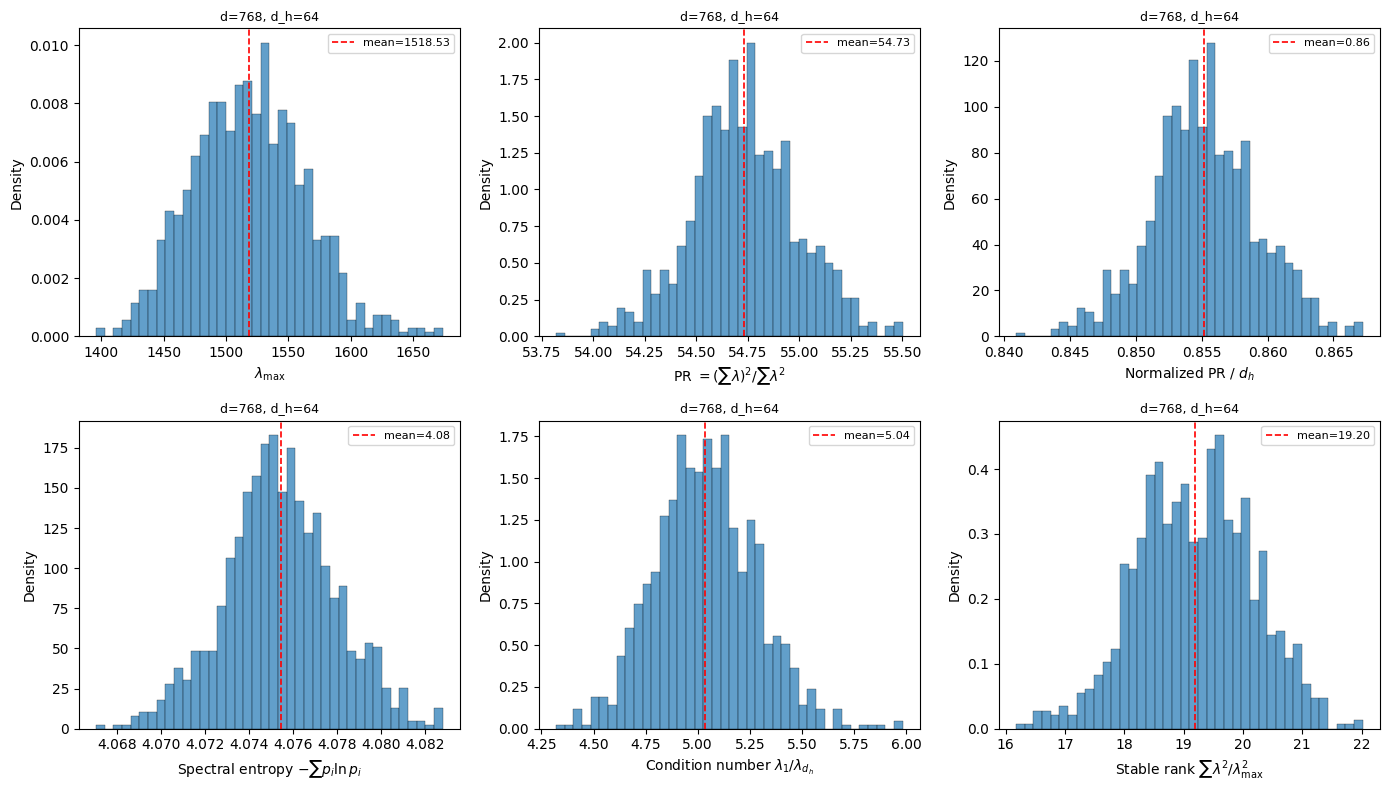

In [25]:
# Single configuration: GPT-2 scale (d=768, d_h=64)
stats_gpt2, singular_values = collect_eig_stats(d_model=768, d_head=64, n_samples=1000)
plot_stat_distributions(stats_gpt2, d_model=768, d_head=64)

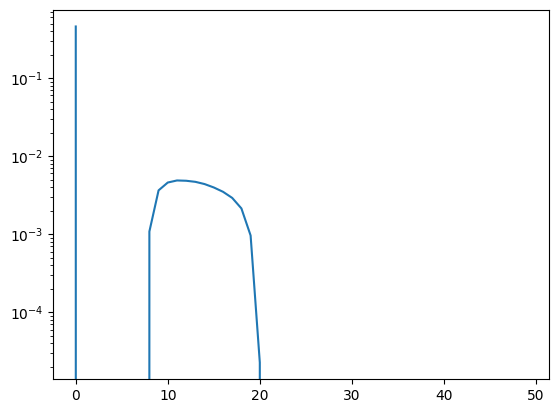

In [26]:
ax = plt.subplot()
h, _ = np.histogram(singular_values, bins=sv_bins, density=True)
ax.plot(h)
ax.set_yscale("log")
plt.show()

## Analytic Predictions: Exact Moments and MP Approximation

For $W_{QK} = W_Q W_K / \sqrt{d}$ with i.i.d. $N(0,\sigma^2)$ entries, the squared
singular values $\lambda_i = s_i^2$ follow a product-ensemble distribution (not
Marchenko–Pastur). However, MP becomes a useful approximation when $\gamma = d_h/d$
is small, because $\frac{1}{d} W_Q^T W_Q \to \sigma^2 I$ and the product collapses
to a single scaled Wishart.

**Exact product-ensemble moments** (Isserlis' theorem on $E[\text{tr}(M^k)]$):

| Quantity | Exact | MP approximation |
|---|---|---|
| $E[\lambda]$ | $\hat\sigma^2 = d\sigma^4$ | same |
| $E[\lambda^2]$ | $\hat\sigma^4(1 + 2\gamma) + O(d)$ | $\hat\sigma^4(1 + \gamma)$ |
| PR | $d_h / (1 + 2\gamma)$ | $d_h / (1 + \gamma)$ |

**Exact spectral edges** (S-transform of the free multiplicative convolution):

The S-transform of MP$(\gamma)$ is $S(z) = 1/(1+\gamma z)$. For the product of two
free MP variables, $S_{\text{prod}}(z) = 1/(1+\gamma z)^2$. The spectral edges follow
from the critical points of $\psi^{-1}(z) = z/[(1+z)(1+\gamma z)^2]$:

$$z_\pm = \frac{-1 \pm \sqrt{1 + 8/\gamma}}{4}, \qquad
\lambda_\pm = \hat\sigma^2 \cdot \frac{(1+z_\pm)(1+\gamma z_\pm)^2}{z_\pm}$$

These give the exact condition number $\lambda_+/\lambda_-$ and correct the ~20–30%
error in the MP edges. Remaining MC-vs-exact discrepancies (~3%) are Tracy–Widom
finite-size corrections at the spectral edges.

In [6]:
def marchenko_pastur_density(lam, gamma, sigma_hat_sq):
    """Standard MP eigenvalue density."""
    lam = np.asarray(lam, dtype=float)
    lam_min = sigma_hat_sq * (1 - np.sqrt(gamma))**2
    lam_max = sigma_hat_sq * (1 + np.sqrt(gamma))**2
    rho = np.zeros_like(lam)
    mask = (lam >= lam_min) & (lam <= lam_max)
    l = lam[mask]
    rho[mask] = np.sqrt((lam_max - l) * (l - lam_min)) / (2 * np.pi * sigma_hat_sq * gamma * l)
    return rho


def product_ensemble_edges(d, d_h, sigma=1.0):
    """Exact spectral edges from S-transform of free multiplicative convolution.
    
    Critical points of psi^{-1}(z) = z / [(1+z)(1+gamma*z)^2].
    """
    gamma = d_h / d
    alpha = np.sqrt(1 + 8/gamma)
    z_plus  = (-1 + alpha) / 4
    z_minus = (-1 - alpha) / 4
    def inv_psi(z):
        return (1 + z) * (1 + gamma*z)**2 / z
    scale = d * sigma**4
    return scale * inv_psi(z_minus), scale * inv_psi(z_plus)  # (lam_min, lam_max)


def mp_predictions_direct(d, d_h, sigma=1.0):
    """Closed-form MP predictions for eigenvalue statistics."""
    gamma = d_h / d
    s2 = d * sigma**4

    lam_max = s2 * (1 + np.sqrt(gamma))**2
    lam_min = s2 * (1 - np.sqrt(gamma))**2
    cond = lam_max / lam_min if lam_min > 0 else np.inf

    E_lam = s2
    E_lam2 = (1 + gamma) * s2**2
    pr = d_h * E_lam**2 / E_lam2   # d_h / (1 + gamma)
    npr = pr / d_h                   # 1 / (1 + gamma)
    stable_rank = d_h * E_lam2 / lam_max**2

    return {
        "max": lam_max, "condition_number": cond,
        "participation_ratio": pr, "normalized_participation_ratio": npr,
        "stable_rank": stable_rank,
        "lam_min": lam_min, "E_lam": E_lam, "E_lam2": E_lam2,
    }


def exact_predictions_direct(d, d_h, sigma=1.0):
    """Exact product-ensemble predictions: Isserlis moments + S-transform edges."""
    gamma = d_h / d
    s2 = d * sigma**4

    E_lam = s2
    E_lam2_exact = sigma**8 * (d**2 + 2*d*d_h + 2*d + d_h + 3)
    sum_lam = E_lam * d_h
    sum_lam2 = E_lam2_exact * d_h

    pr = sum_lam**2 / sum_lam2 if sum_lam2 > 0 else 0
    npr = pr / d_h if d_h > 0 else 0

    lam_min, lam_max = product_ensemble_edges(d, d_h, sigma)
    stable_rank = sum_lam2 / lam_max**2 if lam_max > 0 else 0

    return {
        "max": lam_max,
        "condition_number": lam_max / lam_min if lam_min > 0 else np.inf,
        "participation_ratio": pr,
        "normalized_participation_ratio": npr,
        "stable_rank": stable_rank,
        "lam_min": lam_min,
        "E_lam": E_lam, "E_lam2": E_lam2_exact,
    }


def mp_predictions_numerical(d, d_h, sigma=1.0, n_quad=5000):
    """Numerical integration over the MP eigenvalue density."""
    gamma = d_h / d
    s2 = d * sigma**4

    lam_min = s2 * (1 - np.sqrt(gamma))**2
    lam_max = s2 * (1 + np.sqrt(gamma))**2

    lam_grid = np.linspace(lam_min + 1e-10, lam_max - 1e-10, n_quad)
    rho = marchenko_pastur_density(lam_grid, gamma, s2)

    norm = np.trapezoid(rho, lam_grid)
    E_lam = np.trapezoid(lam_grid * rho, lam_grid) / norm
    E_lam2 = np.trapezoid(lam_grid**2 * rho, lam_grid) / norm

    sum_lam = E_lam * d_h
    sum_lam2 = E_lam2 * d_h

    pr = sum_lam**2 / sum_lam2 if sum_lam2 > 0 else 0
    npr = pr / d_h if d_h > 0 else 0
    stable_rank = sum_lam2 / lam_max**2 if lam_max > 0 else 0
    cond = lam_max / lam_min if lam_min > 0 else np.inf

    # Spectral entropy via quantile sampling
    ds = lam_grid[1] - lam_grid[0]
    cdf = np.cumsum(rho * ds)
    cdf = cdf / cdf[-1]
    u = np.linspace(0, 1, d_h + 2)[1:-1]
    lam_quantiles = np.interp(u, cdf, lam_grid)
    p_discrete = lam_quantiles / np.sum(lam_quantiles)
    p_discrete = p_discrete[p_discrete > 0]
    spectral_entropy = -np.sum(p_discrete * np.log(p_discrete))

    return {
        "max": lam_max, "condition_number": cond,
        "participation_ratio": pr, "normalized_participation_ratio": npr,
        "stable_rank": stable_rank, "spectral_entropy": spectral_entropy,
        "lam_min": lam_min, "E_lam": E_lam, "E_lam2": E_lam2,
    }


# Sanity check: direct MP vs numerical MP vs exact product at GPT-2 scale
pred_mp = mp_predictions_direct(768, 64)
pred_ex = exact_predictions_direct(768, 64)
pred_nu = mp_predictions_numerical(768, 64)
print("d=768, d_h=64, sigma=1:")
print(f"{'':>30s}  {'MP direct':>12s}  {'MP numer':>12s}  {'Exact prod':>12s}")
print("-" * 75)
for k in ["max", "condition_number", "participation_ratio",
          "normalized_participation_ratio", "stable_rank", "E_lam", "E_lam2"]:
    vm = pred_mp.get(k, float('nan'))
    vn = pred_nu.get(k, float('nan'))
    ve = pred_ex.get(k, float('nan'))
    print(f"{k:>30s}  {vm:12.4f}  {vn:12.4f}  {ve:12.4f}")

d=768, d_h=64, sigma=1:
                                   MP direct      MP numer    Exact prod
---------------------------------------------------------------------------
                           max     1275.4050     1275.4050     1564.2261
              condition_number        3.2821        3.2821        5.3857
           participation_ratio       59.0769       59.0770       54.7296
normalized_participation_ratio        0.9231        0.9231        0.8552
                   stable_rank       25.1402       25.1402       18.0410
                         E_lam      768.0000      768.0007      768.0000
                        E_lam2   638976.0000   638976.5535   689731.0000


### Wishart validation

To confirm the MP density and direct formulas are correct, replace the product
$W_Q W_K / \sqrt{d}$ with SVD of the rectangular $W_Q$ itself. The squared
singular values of a $d \times d_h$ Gaussian matrix are eigenvalues of
$W_Q^T W_Q$, a Wishart matrix — so MP should be exact (up to finite-size
fluctuations at the edges).

Note: `W_Q W_Q^T / \sqrt{d}` does **not** work for this test. That matrix is
symmetric PSD, so SVD returns its eigenvalues as singular values directly. The
code then squares them, producing $\mu_i^2 / d$ instead of $\mu_i$.

In [7]:
def generate_wishart(d_n, d_m, mu=0, sigma=1):
    """SVD of rectangular W_Q: squared SVs are Wishart eigenvalues."""
    W_Q = np.random.normal(loc=mu, scale=sigma, size=(d_n, d_m))
    _, S, _ = torch.linalg.svd(torch.tensor(W_Q))
    P_w, _ = np.histogram(W_Q.flatten(), w_bins, density=True)
    P_s, _ = np.histogram(S, sv_bins, density=True)
    return S, torch.tensor(P_w, dtype=float), torch.tensor(P_s, dtype=float)

def collect_wishart_stats(d_model, d_head, n_samples=500, sigma=1.0):
    """Like collect_eig_stats but using rectangular SVD (true Wishart)."""
    stat_names = [
        "max", "participation_ratio", "normalized_participation_ratio",
        "spectral_entropy", "condition_number", "stable_rank"
    ]
    stats = {k: np.zeros(n_samples) for k in stat_names}
    for i in range(n_samples):
        S, _, _ = generate_wishart(d_model, d_head, mu=0, sigma=sigma)
        S_np = S.numpy() if hasattr(S, 'numpy') else np.array(S)
        eigenvalues = S_np**2
        for k in stat_names:
            stats[k][i] = compute_eig_stat(eigenvalues, k, d_model, d_head)
    return stats

# MP predictions use sigma_hat^2 = d*sigma^2 for single Wishart (not d*sigma^4)
def mp_predictions_wishart(d, d_h, sigma=1.0):
    """MP predictions for eigenvalues of W_Q^T W_Q (single Wishart)."""
    gamma = d_h / d
    s2 = d * sigma**2  # note: sigma^2 not sigma^4

    lam_max = s2 * (1 + np.sqrt(gamma))**2
    lam_min = s2 * (1 - np.sqrt(gamma))**2
    cond = lam_max / lam_min if lam_min > 0 else np.inf

    E_lam = s2
    E_lam2 = (1 + gamma) * s2**2
    pr = d_h * E_lam**2 / E_lam2
    npr = pr / d_h
    stable_rank = d_h * E_lam2 / lam_max**2

    return {
        "max": lam_max, "condition_number": cond,
        "participation_ratio": pr, "normalized_participation_ratio": npr,
        "stable_rank": stable_rank,
    }

# Run validation
d_model = 768
d_h_test = [768, 192, 64, 24]
n_samples = 100

print(f"Wishart validation: SVD of rectangular W_Q (d={d_model})")
print(f"{'d_h':>5s}  {'stat':>25s}  {'MC mean':>10s}  {'MP':>10s}  {'rel err':>10s}")
print("-" * 70)
for d_h in d_h_test:
    w_stats = collect_wishart_stats(d_model, d_h, n_samples=n_samples)
    w_mp = mp_predictions_wishart(d_model, d_h)
    for k in ["participation_ratio", "normalized_participation_ratio", "max", "condition_number"]:
        mc_val = np.mean(w_stats[k])
        mp_val = w_mp[k]
        rel = (mc_val - mp_val) / mp_val if mp_val != 0 else float('nan')
        print(f"{d_h:5d}  {k:>25s}  {mc_val:10.3f}  {mp_val:10.3f}  {rel:+10.4f}")
    print()

Wishart validation: SVD of rectangular W_Q (d=768)
  d_h                       stat     MC mean          MP     rel err
----------------------------------------------------------------------
  768        participation_ratio     383.809     384.000     -0.0005
  768  normalized_participation_ratio       0.500       0.500     -0.0005
  768                        max    3043.386    3072.000     -0.0093
  768           condition_number  97957120653.520         inf        +nan



/var/folders/_5/w5f7n1zx5t521cn85gjbd2400000gn/T/ipykernel_13858/2934174184.py:60: RuntimeWarning: invalid value encountered in scalar divide
  rel = (mc_val - mp_val) / mp_val if mp_val != 0 else float('nan')


  192        participation_ratio     153.423     153.600     -0.0011
  192  normalized_participation_ratio       0.799       0.800     -0.0011
  192                        max    1702.348    1728.000     -0.0148
  192           condition_number       8.585       9.000     -0.0461

   64        participation_ratio      59.012      59.077     -0.0011
   64  normalized_participation_ratio       0.922       0.923     -0.0011
   64                        max    1247.956    1275.405     -0.0215
   64           condition_number       3.104       3.282     -0.0542

   24        participation_ratio      23.244      23.273     -0.0012
   24  normalized_participation_ratio       0.969       0.970     -0.0012
   24                        max    1036.338    1063.529     -0.0256
   24           condition_number       1.926       2.043     -0.0575



d_h = 768 (n_h = 1)...
d_h = 384 (n_h = 2)...
d_h = 192 (n_h = 4)...
d_h = 96 (n_h = 8)...
d_h = 64 (n_h = 12)...
d_h = 48 (n_h = 16)...
d_h = 24 (n_h = 32)...


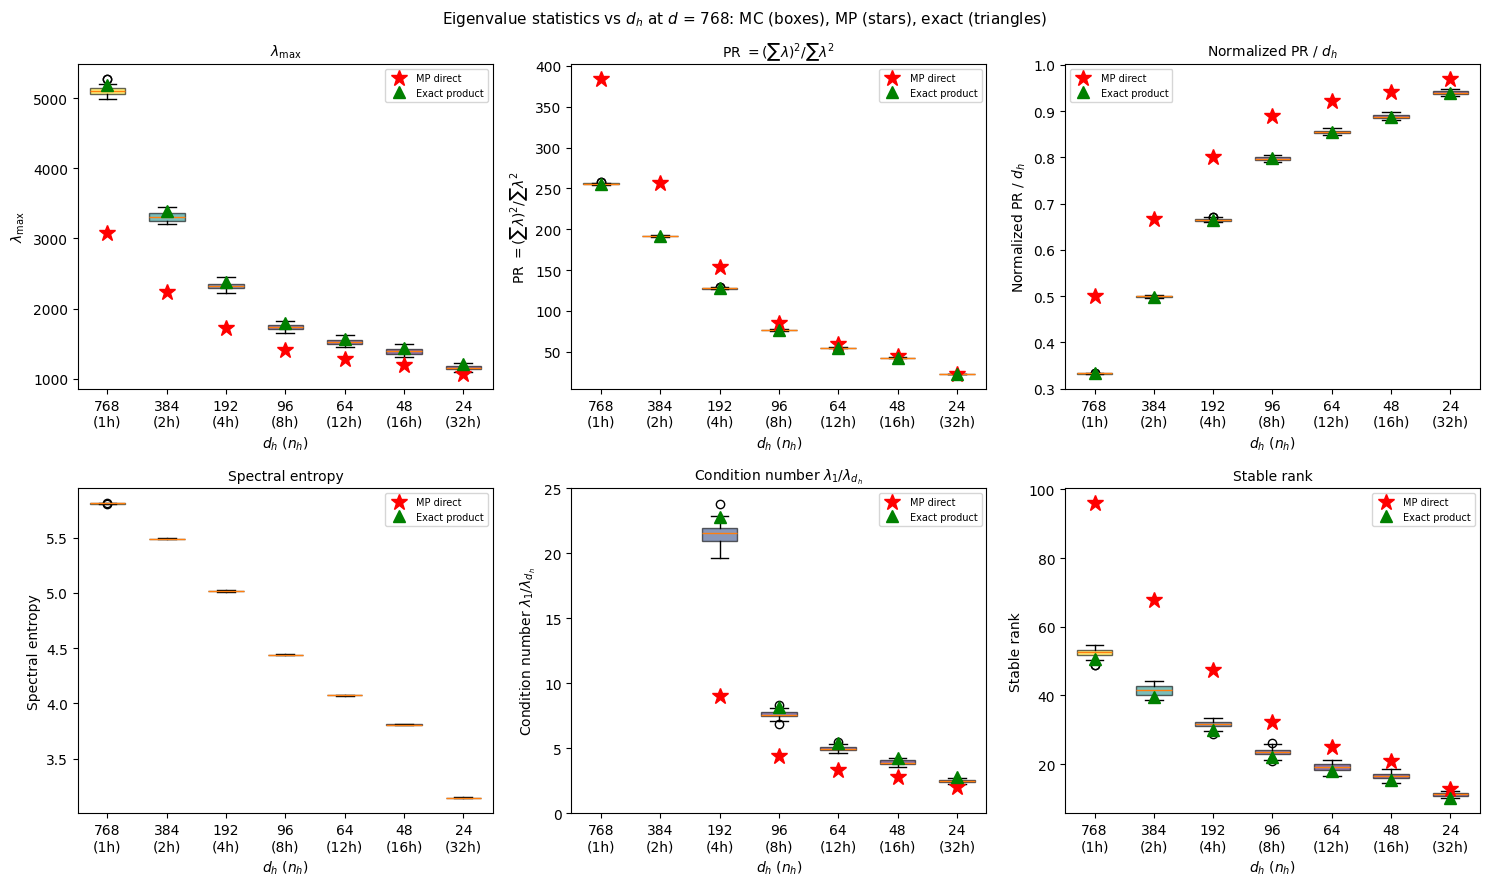

In [17]:
# Compare across d_h values at fixed d=768
d_model = 768
d_h_values = [768, 384, 192, 96, 64, 48, 24]
n_samples = 30

stat_names = ["max", "participation_ratio", "normalized_participation_ratio",
              "spectral_entropy", "condition_number", "stable_rank"]
nice_names = {
    "max": r"$\lambda_{\max}$",
    "participation_ratio": r"PR $= (\sum \lambda)^2 / \sum \lambda^2$",
    "normalized_participation_ratio": r"Normalized PR / $d_h$",
    "spectral_entropy": r"Spectral entropy",
    "condition_number": r"Condition number $\lambda_1 / \lambda_{d_h}$",
    "stable_rank": r"Stable rank",
}

all_stats = {}
for d_h in d_h_values:
    print(f"d_h = {d_h} (n_h = {d_model // d_h})...")
    all_stats[d_h] = collect_eig_stats(d_model, d_h, n_samples=n_samples)

# Three sets of analytic predictions
mp_direct = {d_h: mp_predictions_direct(d_model, d_h) for d_h in d_h_values}
mp_numer  = {d_h: mp_predictions_numerical(d_model, d_h) for d_h in d_h_values}
exact_dir = {d_h: exact_predictions_direct(d_model, d_h) for d_h in d_h_values}

# Box plot: MC samples with MP (stars), numerical (diamonds), exact (triangles)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for idx, stat in enumerate(stat_names):
    ax = axes[idx]
    data = [all_stats[d_h][stat] for d_h in d_h_values]
    labels = [f"{d_h}\n({d_model//d_h}h)" for d_h in d_h_values]
    bp = ax.boxplot(data, tick_labels=labels, patch_artist=True, widths=0.6)
    for patch, d_h in zip(bp['boxes'], d_h_values):
        patch.set_facecolor(plt.cm.viridis(d_h / d_model))
        patch.set_alpha(0.6)
    x_pos = range(1, len(d_h_values) + 1)
    mp_vals = [mp_direct[d_h].get(stat, np.nan) for d_h in d_h_values]
    ex_vals = [exact_dir[d_h].get(stat, np.nan) for d_h in d_h_values]
    ax.plot(x_pos, mp_vals, 'r*', markersize=12, zorder=5, label="MP direct")
    ax.plot(x_pos, ex_vals, 'g^', markersize=8, zorder=5, label="Exact product")
    ax.set_xlabel(r"$d_h$ ($n_h$)")
    ax.set_ylabel(nice_names[stat])
    ax.set_title(nice_names[stat], fontsize=10)
    ax.legend(fontsize=7, loc='best')
    if idx == 4:
        ax.set_ylim(0,25)
fig.suptitle(f"Eigenvalue statistics vs $d_h$ at $d$ = {d_model}: MC (boxes), MP (stars), exact (triangles)", fontsize=11)
plt.tight_layout()
plt.show()

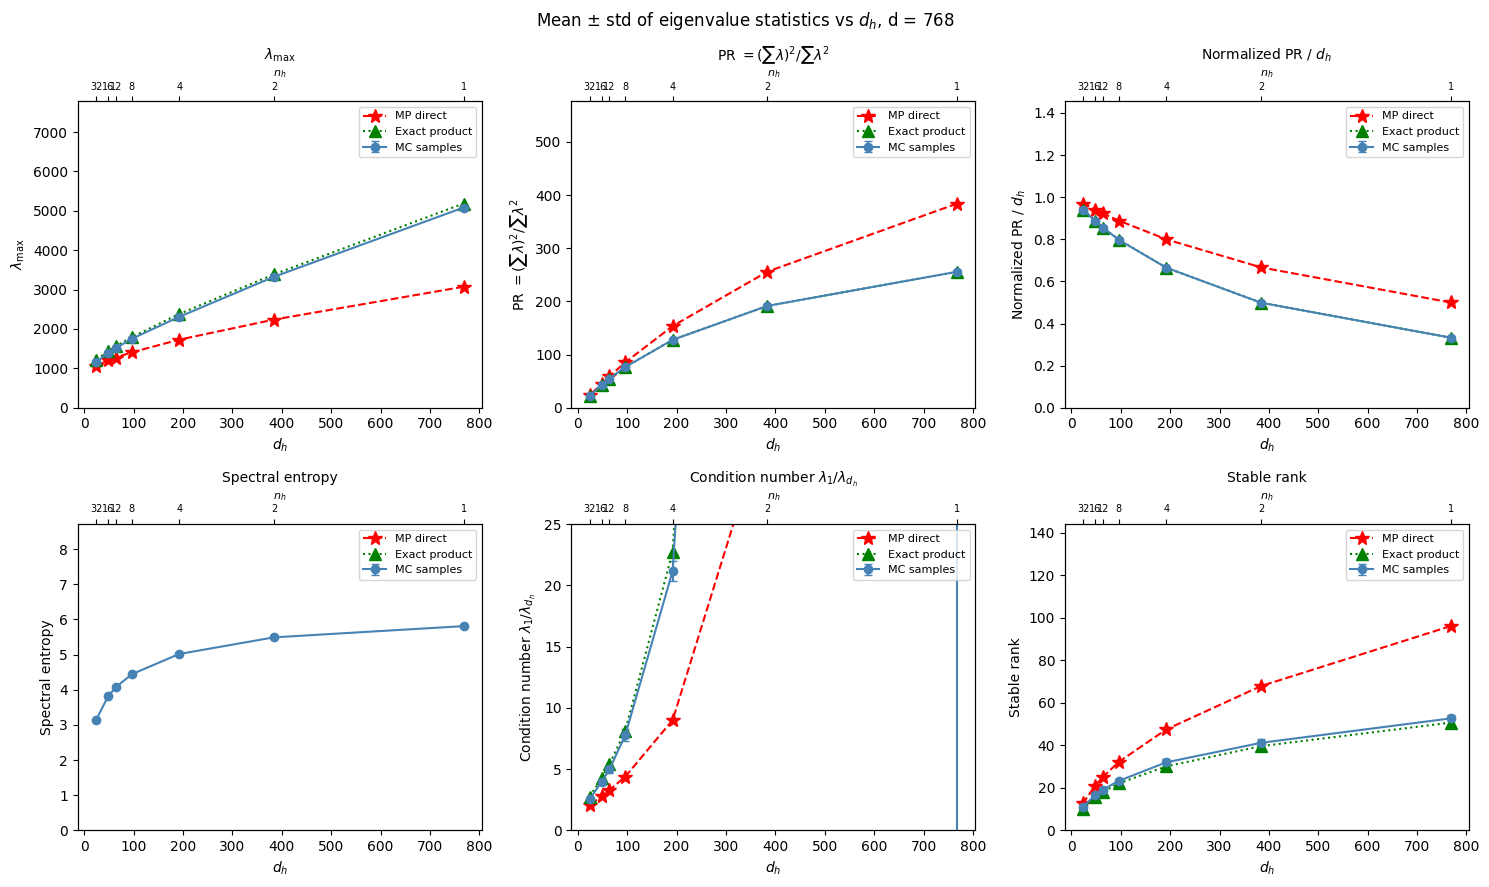

In [15]:
# Means and relative widths vs d_h, with MP and exact predictions
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for idx, stat in enumerate(stat_names):
    ax = axes[idx]
    means = [np.mean(all_stats[d_h][stat]) for d_h in d_h_values]
    stds  = [np.std(all_stats[d_h][stat]) for d_h in d_h_values]
    mp_vals = [mp_direct[d_h].get(stat, np.nan) for d_h in d_h_values]
    ex_vals = [exact_dir[d_h].get(stat, np.nan) for d_h in d_h_values]
    finite = [x for x in mp_vals + ex_vals + means if np.isfinite(x)]
    ymax = max(finite) if finite else 1
    ax.errorbar(d_h_values, means, yerr=stds, fmt='o-', capsize=3, color='steelblue', label='MC samples')
    ax.plot(d_h_values, mp_vals, 'r*--', markersize=10, label='MP direct')
    ax.plot(d_h_values, ex_vals, 'g^:', markersize=8, label='Exact product')
    ax.set_xlabel(r"$d_h$")
    ax.set_ylabel(nice_names[stat])
    ax.set_title(nice_names[stat], fontsize=10)
    ax.set_ylim(0, ymax * 1.5)
    if idx == 4:
        ax.set_ylim(0, 25)

        
    ax.legend(fontsize=8)
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(d_h_values)
    ax2.set_xticklabels([str(d_model // d_h) for d_h in d_h_values], fontsize=7)
    ax2.set_xlabel(r"$n_h$", fontsize=8)
fig.suptitle(f"Mean ± std of eigenvalue statistics vs $d_h$, d = {d_model}", fontsize=12)
plt.tight_layout()
plt.show()

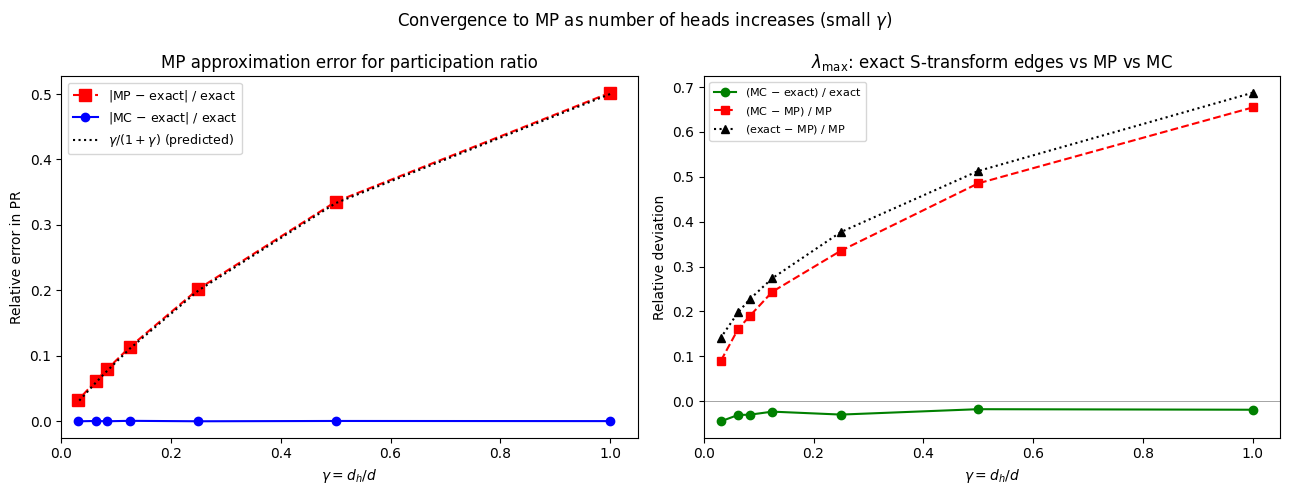

In [10]:
# Convergence to MP: relative error vs gamma
gammas = np.array([d_h / d_model for d_h in d_h_values])
stat_names_conv = ["participation_ratio", "normalized_participation_ratio", "max", "condition_number"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: PR relative error (exact vs MP vs MC)
ax = axes[0]
mp_pr  = np.array([mp_direct[dh]["participation_ratio"] for dh in d_h_values])
ex_pr  = np.array([exact_dir[dh]["participation_ratio"] for dh in d_h_values])
mc_pr  = np.array([np.mean(all_stats[dh]["participation_ratio"]) for dh in d_h_values])
ax.plot(gammas, abs(mp_pr - ex_pr) / ex_pr, 'rs--', markersize=8, label=r"$|$MP $-$ exact$|$ / exact")
ax.plot(gammas, abs(mc_pr - ex_pr) / ex_pr, 'bo-', markersize=6, label=r"$|$MC $-$ exact$|$ / exact")
ax.plot(gammas, gammas / (1 + gammas), 'k:', lw=1.5, label=r"$\gamma/(1+\gamma)$ (predicted)")
ax.set_xlabel(r"$\gamma = d_h / d$")
ax.set_ylabel("Relative error in PR")
ax.set_title("MP approximation error for participation ratio")
ax.legend(fontsize=9)
ax.set_xlim(0, 1.05)

# Right: max eigenvalue — exact edges vs MP edges vs MC
ax = axes[1]
mp_max = np.array([mp_direct[dh]["max"] for dh in d_h_values])
ex_max = np.array([exact_dir[dh]["max"] for dh in d_h_values])
mc_max = np.array([np.mean(all_stats[dh]["max"]) for dh in d_h_values])
ax.plot(gammas, (mc_max - ex_max) / ex_max, 'go-', markersize=6, label=r"(MC $-$ exact) / exact")
ax.plot(gammas, (mc_max - mp_max) / mp_max, 'rs--', markersize=6, label=r"(MC $-$ MP) / MP")
ax.plot(gammas, (ex_max - mp_max) / mp_max, 'k^:', markersize=6, label=r"(exact $-$ MP) / MP")
ax.axhline(0, color='gray', ls='-', lw=0.5)
ax.set_xlabel(r"$\gamma = d_h / d$")
ax.set_ylabel(r"Relative deviation")
ax.set_title(r"$\lambda_{\max}$: exact S-transform edges vs MP vs MC")
ax.legend(fontsize=8)
ax.set_xlim(0, 1.05)

fig.suptitle("Convergence to MP as number of heads increases (small $\\gamma$)", fontsize=12)
plt.tight_layout()
plt.show()